In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from quantlib.research.data import (
    fetch_indicator_dataframe,
)
from quantlib.building_blocks.strategy import indicators
from quantlib.building_blocks.trading_environment import (
    instruments,
)
from quantlib.building_blocks import bars, intervals
from quantsdk.tools.rounding import round_down
from typing import Literal


In [2]:
target_instrument = instruments.BinanceFuturesUSDM.DOGEUSDT
candle_size = intervals.CandlestickInterval(hours=4)
price_open = indicators.Open(
    instrument=target_instrument,
    bar_type=bars.CandlestickTimeBar(
        interval=candle_size,
    ),
)
price_close = indicators.Close(
    instrument=target_instrument,
    bar_type=bars.CandlestickTimeBar(
        interval=candle_size,
    ),
)
volume = indicators.Volume(
    instrument=target_instrument,
    bar_type=bars.CandlestickTimeBar(
        interval=candle_size,
    ),
)

indicator_df = fetch_indicator_dataframe(
    indicators=[
        indicators.OpenTimestamp(
            instrument=target_instrument,
            bar_type=bars.CandlestickTimeBar(
                interval=candle_size,
            ),
        ).alias("open_timestamp"),
        price_open.alias("open"),
        price_close.alias("close"),
        volume.alias("volume"),
    ],
    start_date="2022-12-01", # ! I want to backtest from 2023 onwards. However, requesting data from 2022-12 to ensure the first candle of 2023 features the appropriate values of rolling operations.
    end_date="2024-01-01",
)

INFO:quantops.controls.cached_secret:Fetching supported backtesting dates...
INFO:quantde.market_data.history.local_market_data:[quant-de] Processing market data for ['DOGEUSDT']...


[quant-de] Retrieving market data from local db...


In [3]:
indicator_df

,data_available_at_timestamp_integer_ms,data_available_at_datetime,open_timestamp,open,close,volume
0,1669867200000,2022-12-01 04:00:00,2022-12-01 00:00:00,0.10670,0.10448,2.684396e+09
1,1669881600000,2022-12-01 08:00:00,2022-12-01 04:00:00,0.10448,0.10257,2.159824e+09
2,1669896000000,2022-12-01 12:00:00,2022-12-01 08:00:00,0.10255,0.10400,1.823019e+09
3,1669910400000,2022-12-01 16:00:00,2022-12-01 12:00:00,0.10399,0.10187,4.962692e+09
4,1669924800000,2022-12-01 20:00:00,2022-12-01 16:00:00,0.10188,0.10220,1.462048e+09
...,...,...,...,...,...,...
2371,1704009600000,2023-12-31 08:00:00,2023-12-31 04:00:00,0.08974,0.09057,2.193889e+08
2372,1704024000000,2023-12-31 12:00:00,2023-12-31 08:00:00,0.09057,0.09050,2.509276e+08
2373,1704038400000,2023-12-31 16:00:00,2023-12-31 12:00:00,0.09051,0.09019,3.339899e+08
2374,1704052800000,2023-12-31 20:00:00,2023-12-31 16:00:00,0.09019,0.09038,2.950964e+08


In [4]:
# Let the strategy be buys at with (D % 5 = 0 @ 0h) days of max holding period of 12 candles of 4 hours
# Four scenarios: trading the entire balance available, trading a fixed amount of capital, trading a fixed lot size, and computing log returns
initial_capital = 10000
fixed_capital_hypothesis = initial_capital
fixed_lot_hypothesis = 100000
holding_period = 12
df = indicator_df[["open_timestamp", "open", "close", "volume"]].copy()
# df["entry_signal_raw"] = (df["open_timestamp"].dt.day % 5 == 0) & (df["open_timestamp"].dt.hour == 0)

df['green_candle'] = (df['close'] - df['close'].rolling(50).mean()) / df['close'].rolling(50).std() > 2
df['volume_zscore'] = (df['volume'] - df['volume'].rolling(50).mean()) / df['volume'].rolling(50).std()
df['volume_outlier'] = df['volume_zscore'] > 2
df['entry_signal_raw'] = df['green_candle'] & df['volume_outlier']
df["close_log_return"] = np.log(df["close"]).diff()

In [5]:
df = df[df["open_timestamp"].dt.year >= 2023].reset_index(drop=True)

In [6]:
_ix = df[df["entry_signal_raw"]].index[0]
df.iloc[_ix-5:_ix+5]

,open_timestamp,open,close,volume,green_candle,volume_zscore,volume_outlier,entry_signal_raw,close_log_return
43,2023-01-08 04:00:00,0.07185,0.07177,2.765186e+08,False,-1.541982,False,False,-0.000975
44,2023-01-08 08:00:00,0.07178,0.07165,4.317048e+08,False,-1.198045,False,False,-0.001673
45,2023-01-08 12:00:00,0.07165,0.07242,7.994471e+08,False,-0.436362,False,False,0.010689
46,2023-01-08 16:00:00,0.07243,0.07186,7.047641e+08,False,-0.600639,False,False,-0.007763
47,2023-01-08 20:00:00,0.07186,0.07361,1.684798e+09,False,1.462057,False,False,0.024061
48,2023-01-09 00:00:00,0.07361,0.07489,2.657055e+09,True,3.079160,True,True,0.017239
49,2023-01-09 04:00:00,0.07490,0.07494,1.421059e+09,True,0.718620,False,False,0.000667
50,2023-01-09 08:00:00,0.07493,0.07787,2.630483e+09,True,2.703477,True,True,0.038353
51,2023-01-09 12:00:00,0.07788,0.07822,3.420167e+09,True,3.461424,True,True,0.004485
52,2023-01-09 16:00:00,0.07822,0.07684,2.350589e+09,True,1.746524,False,False,-0.017800


In [7]:
df["if_entry_trade_here_will_exit_at_this_index"] = df.index + 12
signal_series = df["entry_signal_raw"].copy()
# create entry_signal_net that accounts for exits
for ix in signal_series.index:
    if signal_series[ix]:
        exit_ix = df["if_entry_trade_here_will_exit_at_this_index"].iloc[ix]

        signal_series.iloc[ix+1:exit_ix+1] = False
df["entry_signal_net"] = signal_series

In [8]:
_ix = df[df["entry_signal_raw"]].index[0]
df.iloc[_ix-5:_ix+20]

,open_timestamp,open,close,volume,green_candle,volume_zscore,volume_outlier,entry_signal_raw,close_log_return,if_entry_trade_here_will_exit_at_this_index,entry_signal_net
43,2023-01-08 04:00:00,0.07185,0.07177,2.765186e+08,False,-1.541982,False,False,-0.000975,55,False
44,2023-01-08 08:00:00,0.07178,0.07165,4.317048e+08,False,-1.198045,False,False,-0.001673,56,False
45,2023-01-08 12:00:00,0.07165,0.07242,7.994471e+08,False,-0.436362,False,False,0.010689,57,False
46,2023-01-08 16:00:00,0.07243,0.07186,7.047641e+08,False,-0.600639,False,False,-0.007763,58,False
47,2023-01-08 20:00:00,0.07186,0.07361,1.684798e+09,False,1.462057,False,False,0.024061,59,False
48,2023-01-09 00:00:00,0.07361,0.07489,2.657055e+09,True,3.079160,True,True,0.017239,60,True
49,2023-01-09 04:00:00,0.07490,0.07494,1.421059e+09,True,0.718620,False,False,0.000667,61,False
50,2023-01-09 08:00:00,0.07493,0.07787,2.630483e+09,True,2.703477,True,True,0.038353,62,False
51,2023-01-09 12:00:00,0.07788,0.07822,3.420167e+09,True,3.461424,True,True,0.004485,63,False
52,2023-01-09 16:00:00,0.07822,0.07684,2.350589e+09,True,1.746524,False,False,-0.017800,64,False


In [9]:
# backtesting solely via pandas operations:
df["positioned_et_end_of_bar"] = (df["entry_signal_net"]).astype(int).shift(1)
df.loc[[i+1 for i in df[df["entry_signal_net"]].index.values + holding_period if i+1 <= df.index[-1]], "positioned_et_end_of_bar"] = -1 # exiting after holding_period bars
df["positioned_et_end_of_bar"] = df["positioned_et_end_of_bar"].cumsum()
df["pd_bt_log_return_daily"] = (df["positioned_et_end_of_bar"]* df["close_log_return"]).shift(1).fillna(0)
df["pd_bt_cumulative_log_return"] = (df["pd_bt_log_return_daily"]).cumsum()


# row by row backtesting:
df["return_trading_entire_balance"] = 0.0
df["return_trading_fixed_capital"] = 0.0
df["return_trading_fixed_lot"] = 0.0
df["return_log"] = 0
balance = initial_capital

i=0
# we will trade at the bar's open, so our prices are either the open prices or the close prices of the previous bar. Will assume close prices of previous bar.
print("entry_signal", "open_timestamp", "will_exit_at", "holding_period", "holding_period in bars", "balance", "volume_to_buy_with_fixed_capital", "entry_price", "exit_price", "actual_return_with_fixed_capital", "actual_return_with_balance", "actual_return_with_fixed_lot", "log_return")
while i < len(df) - holding_period-1:

    open_timestamp = df.iloc[i]["open_timestamp"] 
    # We are the open, so we have access to the previous bar's close price / signal. (i-1)

    if df.iloc[i-1]["entry_signal_raw"]: # trade rule. 
        entry_signal = df.iloc[i-1]["entry_signal_raw"]

        _exiting_index = i + holding_period # as soon as this bar opens, or, as soon as its previous bar closes
        entry_price = df.iloc[i-1]["close"] # close price of the previous bar. We act as soon as the bar closes, and, if we are fast enough, we define the next bar open.
        exit_price = df.iloc[_exiting_index-1]["close"] # analogous to entry 
        will_exit_at = df.iloc[_exiting_index]["open_timestamp"]
        price_change = exit_price - entry_price
        price_pct_change = (price_change) / entry_price
        log_return = np.log(exit_price) - np.log(entry_price)

        volume_to_buy_with_balance = balance / entry_price
        volume_to_buy_with_fixed_capital = fixed_capital_hypothesis / entry_price
        volume_to_buy_with_fixed_lot = fixed_lot_hypothesis

        volume_to_buy_with_balance = round_down(volume_to_buy_with_balance,5)
        volume_to_buy_with_fixed_capital = round_down(volume_to_buy_with_fixed_capital,5)
        volume_to_buy_with_fixed_lot = round_down(volume_to_buy_with_fixed_lot,5)

        actual_return_with_balance = volume_to_buy_with_balance * price_change
        actual_return_with_fixed_capital = volume_to_buy_with_fixed_capital * price_change
        actual_return_with_fixed_lot = volume_to_buy_with_fixed_lot * price_change

        df.loc[_exiting_index, "return_trading_entire_balance"] = actual_return_with_balance
        df.loc[_exiting_index, "return_trading_fixed_capital"] = actual_return_with_fixed_capital
        df.loc[_exiting_index, "return_trading_fixed_lot"] = actual_return_with_fixed_lot
        df.loc[_exiting_index, "return_log"] = log_return

        balance += actual_return_with_balance

        print(entry_signal, open_timestamp, will_exit_at, will_exit_at-open_timestamp, _exiting_index-i,balance, volume_to_buy_with_fixed_capital, entry_price, exit_price, actual_return_with_fixed_capital, actual_return_with_balance, actual_return_with_fixed_capital, log_return)

        i = _exiting_index+1  # skip to the exit point
    else:
        i+=1

entry_signal open_timestamp will_exit_at holding_period holding_period in bars balance volume_to_buy_with_fixed_capital entry_price exit_price actual_return_with_fixed_capital actual_return_with_balance actual_return_with_fixed_lot log_return
True 2023-01-09 04:00:00 2023-01-11 04:00:00 2 days 00:00:00 12 10218.9878488368 133529.17612 0.07489 0.07653 218.98784883680034 218.98784883680034 218.98784883680034 0.02166245056055427
True 2023-01-12 04:00:00 2023-01-14 04:00:00 2 days 00:00:00 12 11227.986773983801 124984.37695 0.08001 0.08791 987.3765779050005 1008.9989251470006 987.3765779050005 0.09416193700105469
True 2023-01-14 12:00:00 2023-01-16 12:00:00 2 days 00:00:00 12 10947.8083667893 116063.13834 0.08616 0.08401 -249.53574743099992 -280.1784071944999 -249.53574743099992 -0.02527019347137749
True 2023-01-22 20:00:00 2023-01-24 20:00:00 2 days 00:00:00 12 10843.7766495038 111794.29849 0.08945 0.0886 -95.0251537165004 -104.03171728550043 -95.0251537165004 -0.009547952343692767
True 2

In [10]:
df

,open_timestamp,open,close,volume,green_candle,volume_zscore,volume_outlier,entry_signal_raw,close_log_return,if_entry_trade_here_will_exit_at_this_index,entry_signal_net,positioned_et_end_of_bar,pd_bt_log_return_daily,pd_bt_cumulative_log_return,return_trading_entire_balance,return_trading_fixed_capital,return_trading_fixed_lot,return_log
0,2023-01-01 00:00:00,0.07022,0.06981,916814011.0,False,-0.299844,False,False,-0.005713,12,False,NaN,0.0,0.000000,0.0,0.0,0.0,0.0
1,2023-01-01 04:00:00,0.06982,0.06943,752917784.0,False,-0.565505,False,False,-0.005458,13,False,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,2023-01-01 08:00:00,0.06942,0.06962,670367958.0,False,-0.710072,False,False,0.002733,14,False,0.0,-0.0,0.000000,0.0,0.0,0.0,0.0
3,2023-01-01 12:00:00,0.06963,0.06972,512840965.0,False,-0.956186,False,False,0.001435,15,False,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,2023-01-01 16:00:00,0.06972,0.07030,948331509.0,False,-0.267123,False,False,0.008285,16,False,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2023-12-31 04:00:00,0.08974,0.09057,219388929.0,False,-1.249981,False,False,0.009206,2197,False,0.0,-0.0,0.297961,0.0,0.0,0.0,0.0
2186,2023-12-31 08:00:00,0.09057,0.09050,250927593.0,False,-1.116706,False,False,-0.000773,2198,False,0.0,0.0,0.297961,0.0,0.0,0.0,0.0
2187,2023-12-31 12:00:00,0.09051,0.09019,333989917.0,False,-0.880887,False,False,-0.003431,2199,False,0.0,-0.0,0.297961,0.0,0.0,0.0,0.0
2188,2023-12-31 16:00:00,0.09019,0.09038,295096436.0,False,-0.981845,False,False,0.002104,2200,False,0.0,-0.0,0.297961,0.0,0.0,0.0,0.0


<Axes: xlabel='open_timestamp'>

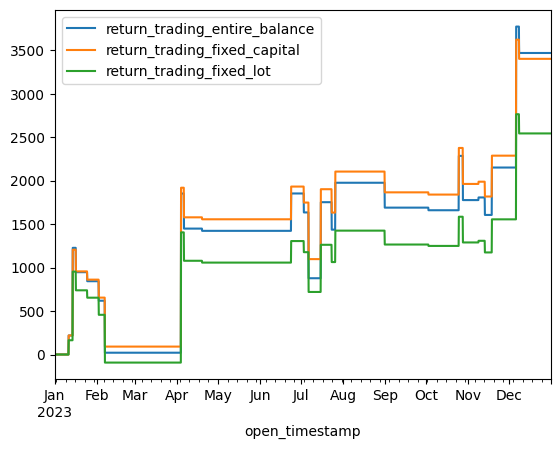

In [11]:
df.set_index("open_timestamp")[["return_trading_entire_balance", "return_trading_fixed_capital", "return_trading_fixed_lot"]].cumsum().plot()

<Axes: >

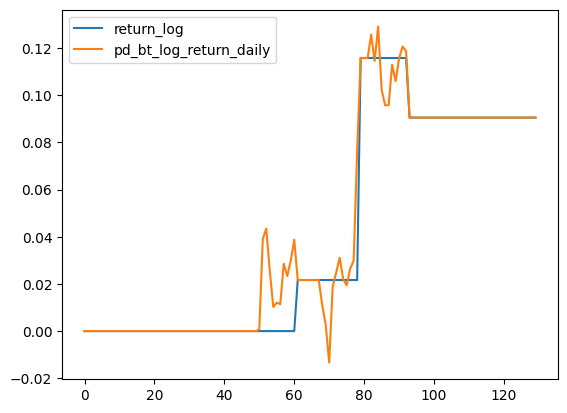

In [12]:
# Because pd_bt_log_return_daily is calculated for every bar, and not only trading bars, it serves as a proxy for marking to market.
df[["return_log", "pd_bt_log_return_daily"]].cumsum()[:130].plot()

In [13]:
# Placing each return on the same scale (a initial capital of 10000):
# Note that some of these scenarios are unfeasible in practice due to the losses change the available balance, which may prevent opening new positions with the same volume as initially intended.

dff = df.set_index("open_timestamp")[["return_trading_entire_balance", "return_trading_fixed_capital", "return_trading_fixed_lot"]].copy()
dff.iloc[0] = initial_capital
dff = dff.cumsum()
dff = dff/initial_capital - 1
dff["log_return"] = df["return_log"].cumsum().values
dff["pd_bt_log_return"] = df["pd_bt_log_return_daily"].cumsum().values

In [14]:
dff

,return_trading_entire_balance,return_trading_fixed_capital,return_trading_fixed_lot,log_return,pd_bt_log_return
open_timestamp,,,,,
2023-01-01 00:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
2023-01-01 04:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
2023-01-01 08:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
2023-01-01 12:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
2023-01-01 16:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
...,...,...,...,...,...
2023-12-31 04:00:00,0.347109,0.340363,0.2545,0.297961,0.297961
2023-12-31 08:00:00,0.347109,0.340363,0.2545,0.297961,0.297961
2023-12-31 12:00:00,0.347109,0.340363,0.2545,0.297961,0.297961


<Axes: xlabel='open_timestamp'>

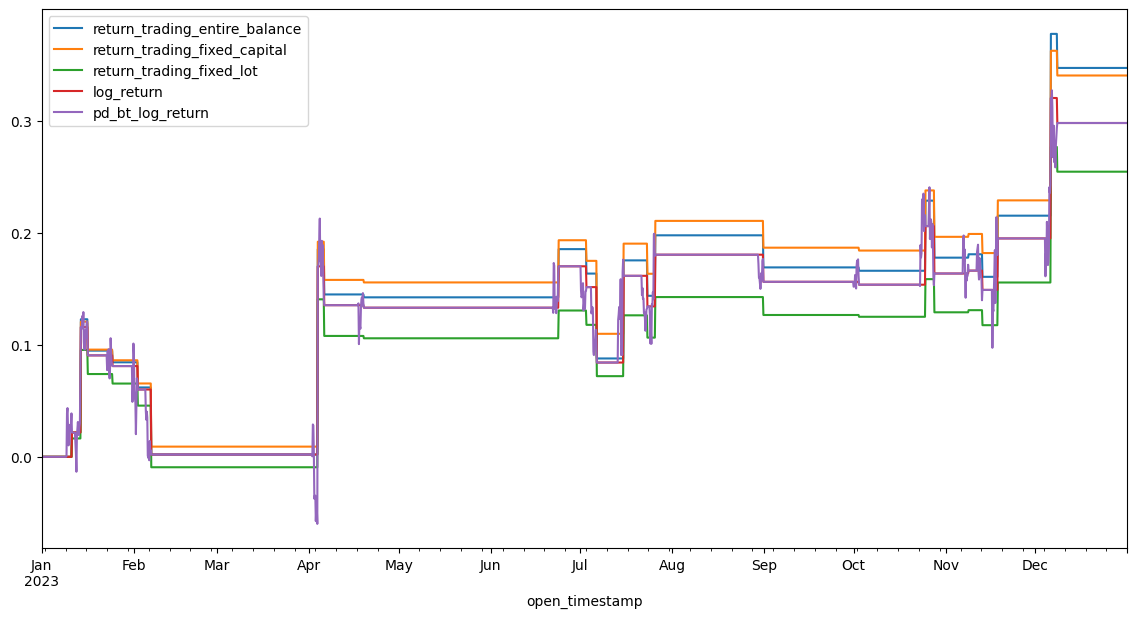

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))
(dff[["return_trading_entire_balance", "return_trading_fixed_capital","return_trading_fixed_lot", "log_return", "pd_bt_log_return"]]).plot(ax=ax)

### Comparison with backtests from quantlib (see appendix A for reference code)

In [16]:
portfolio_history_comparison_scenarios_from_quantlib_backtests = pd.read_csv(
    "portfolio_history_comparison_scenarios_strat_2.csv",
)
portfolio_history_comparison_scenarios_from_quantlib_backtests["date"] = pd.to_datetime(
    portfolio_history_comparison_scenarios_from_quantlib_backtests["date"]
)
portfolio_history_comparison_scenarios_from_quantlib_backtests

,date,symbol,mark_to_market_price,pnl_mm,volume_cum,mean_price,pnl_deals,pnl_mm_this_day,pnl_total,pnl_total_cum,number_of_orders,configuration,slippage,trading_fee,pnl_total_cum_deals,Slippage / Fee
0,2023-01-01,DOGE/USDT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
1,2023-01-02,DOGE/USDT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
2,2023-01-03,DOGE/USDT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
3,2023-01-04,DOGE/USDT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
4,2023-01-05,DOGE/USDT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,2023-12-27,DOGE/USDT,0.093799,0.0,0.0,0.0,0.0,0.0,0.0,3028.035135,0.0,full_balance,0.0002,0.0005,3028.035135,0.02% - 0.05%
5836,2023-12-28,DOGE/USDT,0.091818,0.0,0.0,0.0,0.0,0.0,0.0,3028.035135,0.0,full_balance,0.0002,0.0005,3028.035135,0.02% - 0.05%
5837,2023-12-29,DOGE/USDT,0.091048,0.0,0.0,0.0,0.0,0.0,0.0,3028.035135,0.0,full_balance,0.0002,0.0005,3028.035135,0.02% - 0.05%
5838,2023-12-30,DOGE/USDT,0.090088,0.0,0.0,0.0,0.0,0.0,0.0,3028.035135,0.0,full_balance,0.0002,0.0005,3028.035135,0.02% - 0.05%


In [17]:
def plot_quantlib_vs_notebook(
    exposure_scenario: Literal["fixed_margin", "fixed_capital", "fixed_lots", "full_balance"],
    pnl_origin: Literal["deals", "mark_to_market_included"]=None
):
    fig, ax = plt.subplots(figsize=(14, 7))
    
    subset = portfolio_history_comparison_scenarios_from_quantlib_backtests[
    (portfolio_history_comparison_scenarios_from_quantlib_backtests["configuration"] == exposure_scenario)
    & (portfolio_history_comparison_scenarios_from_quantlib_backtests["Slippage / Fee"] == "0.00% - 0.00%")
    ].set_index("date")

    plt.plot(subset.index, subset["pnl_total_cum_deals"], label=f"quantlib - {exposure_scenario} - no costs - deals", color="black", linewidth=2)
    plt.plot(subset.index, subset["pnl_total_cum"], label=f"quantlib - {exposure_scenario} - no costs - MtM", color="black", linewidth=1, linestyle="--")

    df.set_index("open_timestamp")[["return_trading_entire_balance", "return_trading_fixed_capital", "return_trading_fixed_lot"]].cumsum().plot(ax=ax)

    ax.legend()
    plt.title(f"Cumulative Returns Comparison - quantlib '{exposure_scenario}' vs. Notebook backtests")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Returns [USDT]")
    

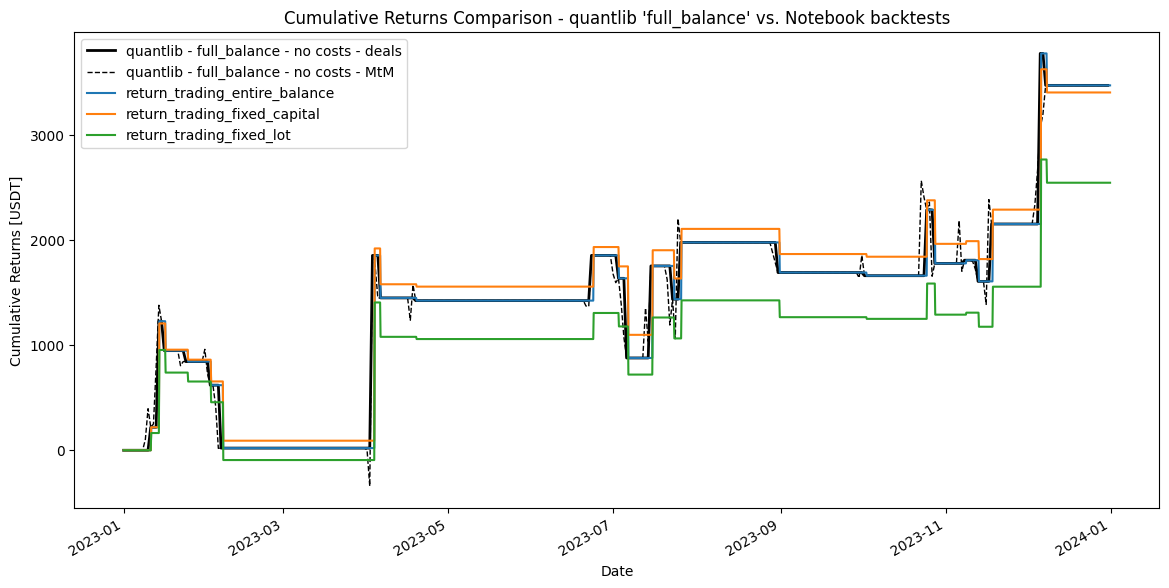

In [18]:
plot_quantlib_vs_notebook("full_balance")

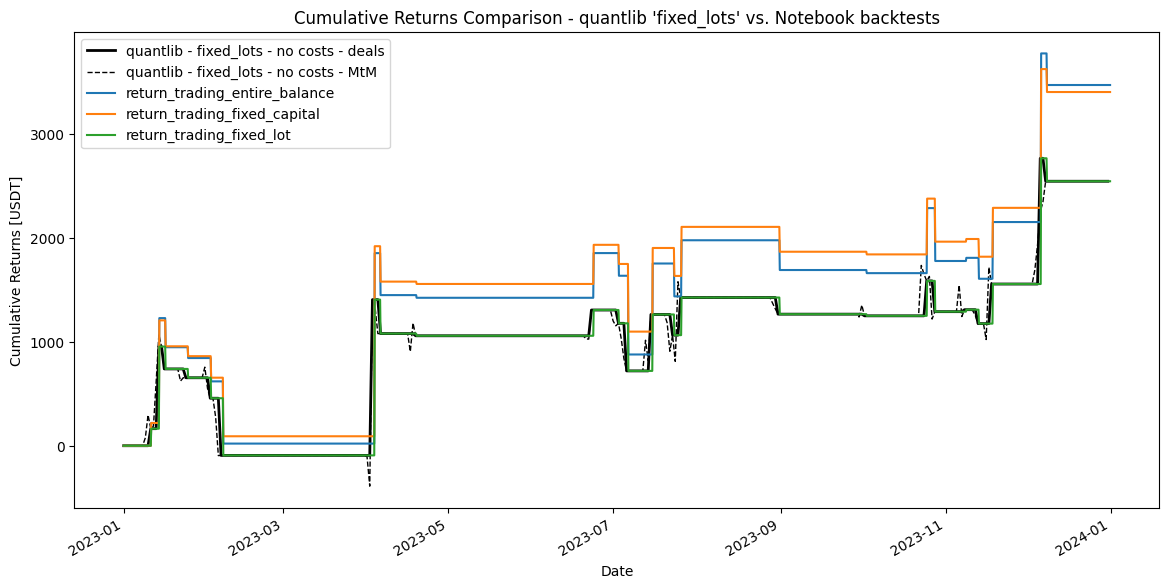

In [19]:
plot_quantlib_vs_notebook("fixed_lots")

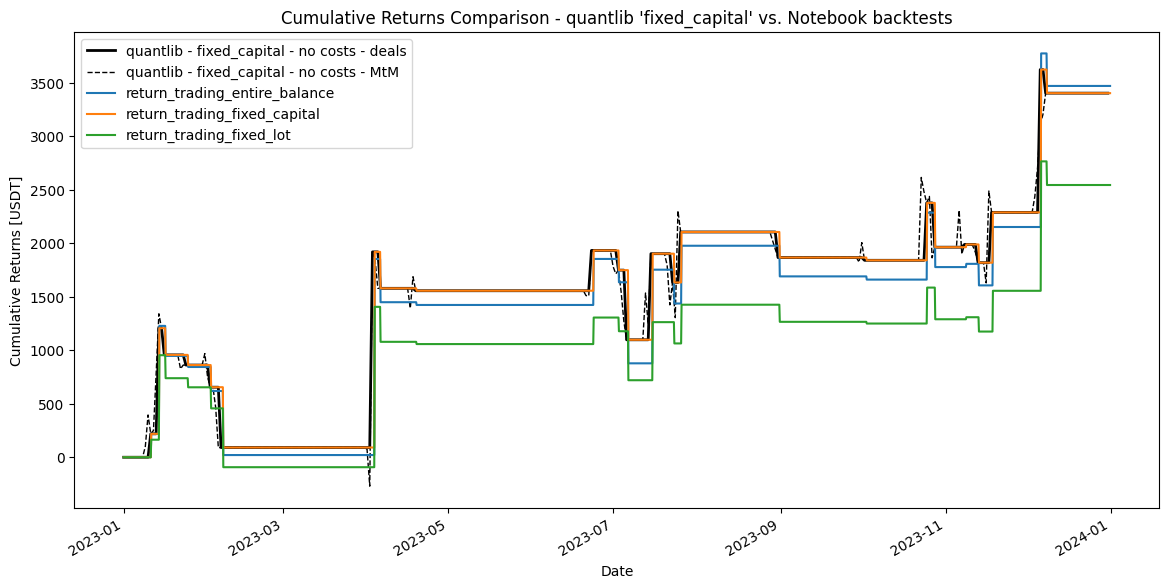

In [20]:
plot_quantlib_vs_notebook("fixed_capital")

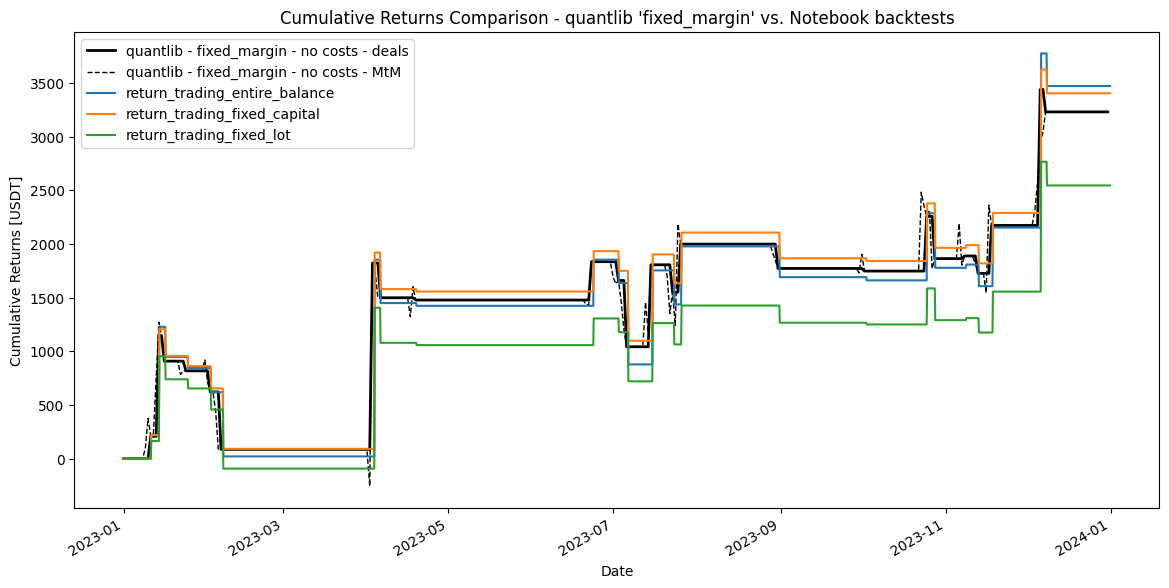

In [21]:
plot_quantlib_vs_notebook("fixed_margin")

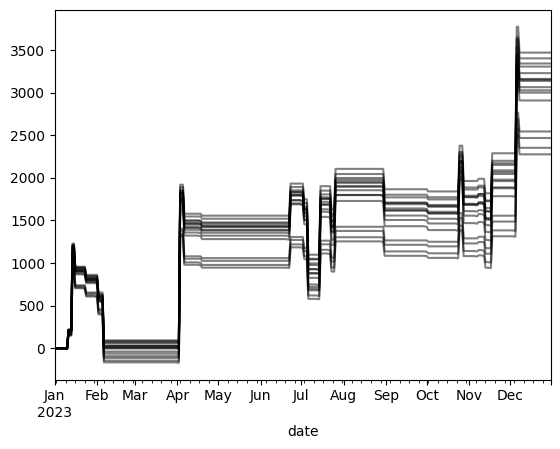

In [22]:
# Curves from quantlib - with costs
fig, ax = plt.subplots()
for configuration in portfolio_history_comparison_scenarios_from_quantlib_backtests[
    "configuration"
].unique():
    for slippage_fee in portfolio_history_comparison_scenarios_from_quantlib_backtests[
        "Slippage / Fee"
    ].unique():
        subset = portfolio_history_comparison_scenarios_from_quantlib_backtests[
            (portfolio_history_comparison_scenarios_from_quantlib_backtests["configuration"]
             == configuration)
            & (portfolio_history_comparison_scenarios_from_quantlib_backtests["Slippage / Fee"]
               == slippage_fee)
        ]
        subset.set_index("date")["pnl_total_cum_deals"].plot(ax=ax,color="black",alpha=0.5)

### Appendix A

In [ ]:
import logging
from typing import Literal
from quantlib.backtester import backtest, load_backtest_results
from quantlib.backtester.custom_strategies import (
    UserDefinedStrategyHandler,
    PreparedOrder,
    OrderSide,
)
from quantlib.building_blocks.strategy import (
    indicators,
    take_profit,
    stop_loss,
    trading_signals,
    options,
)
from quantlib.building_blocks import bars, intervals, data_catalogue
from quantlib.building_blocks.trading_environment import instruments
from quantlib.backtester.standards import BacktestStandards
from quantsdk.symbols import TradingSymbol
from quantlib.experimental import PortfolioHolderMetadata
import pandas as pd
import numpy as np
from quantlib.building_blocks.trading_environment import (
    TradingEnvironment,
    markets,
    exchange,
)
from pathlib import Path

logging.basicConfig()
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


pd.options.display.max_columns = None

Configuration = Literal["fixed_margin", "fixed_capital", "fixed_lots", "full_balance"]

portfolio_histories = []
for CONFIGURATION in [
    "fixed_margin",
    "fixed_capital",
    "fixed_lots",
    "full_balance",
]:
    for COST_STRUCTURE in [
        dict(
            slippage=0.00 / 100,
            trading_fee=0.00 / 100,
        ),
        dict(
            slippage=0.02 / 100,
            trading_fee=0.00 / 100,
        ),
        dict(
            slippage=0.00 / 100,
            trading_fee=0.05 / 100,
        ),
        dict(
            slippage=0.02 / 100,
            trading_fee=0.05 / 100,
        ),
    ]:

        class MyStrategy(UserDefinedStrategyHandler):

            def handle_hook(self) -> list[PreparedOrder]:

                initial_capital = 10000
                balance = (
                    initial_capital
                    + self.get_deals_history_dataframe()["profit_net"].sum()
                )
                now = self.get_current_timestamp()
                open_positions = self.get_open_positions()

                _prepared_orders = []

                df = self.query_indicators_as_dataframe(
                    indicators=[
                        indicators.Close(
                            instrument=instruments.BinanceFuturesUSDM.DOGEUSDT,
                            bar_type=bars.CandlestickTimeBar(
                                interval=intervals.CandlestickInterval(hours=4)
                            ),
                        ).alias("close"),
                        indicators.Volume(
                            instrument=instruments.BinanceFuturesUSDM.DOGEUSDT,
                            bar_type=bars.CandlestickTimeBar(
                                interval=intervals.CandlestickInterval(hours=4)
                            ),
                        ).alias("volume"),
                    ]
                )

                df["green_candle"] = (
                    df["close"] - df["close"].rolling(50).mean()
                ) / df["close"].rolling(50).std() > 2
                df["volume_zscore"] = (
                    df["volume"] - df["volume"].rolling(50).mean()
                ) / df["volume"].rolling(50).std()
                df["volume_outlier"] = df["volume_zscore"] > 2
                df["entry_signal_raw"] = df["green_candle"] & df["volume_outlier"]

                should_trade = df.iloc[-1]["entry_signal_raw"]

                if should_trade:
                    for symbol in self.get_trading_symbols(return_type="Instrument"):

                        if not open_positions.get_position_for_symbol(
                            symbol
                        ).positioned:

                            symbol_price = self.query_indicators_as_dataframe(
                                indicators=[
                                    indicators.Close(
                                        instrument=symbol,
                                        bar_type=bars.CandlestickTimeBar(
                                            interval=intervals.CandlestickInterval(
                                                hours=4
                                            )
                                        ),
                                    ).alias("close"),
                                ]
                            )
                            symbol_price = symbol_price["close"].iloc[-1]
                            volume_fixed_capital = 10000 / symbol_price
                            volume_balance = balance / symbol_price
                            volume_fixed_lots = 100000

                            if CONFIGURATION == "fixed_margin":
                                prepare_orders_argument = dict(
                                    symbol=symbol,
                                    leverage=1,
                                    margin_exposure=10000,
                                    target_net_order=True,
                                    target_net_direction="long",
                                )
                            elif CONFIGURATION == "fixed_capital":
                                prepare_orders_argument = dict(
                                    symbol=symbol,
                                    volume=volume_fixed_capital,
                                    order_side=self.order_sides.BUY,
                                )
                            elif CONFIGURATION == "fixed_lots":
                                prepare_orders_argument = dict(
                                    symbol=symbol,
                                    volume=volume_fixed_lots,
                                    order_side=self.order_sides.BUY,
                                )
                            elif CONFIGURATION == "full_balance":
                                prepare_orders_argument = dict(
                                    symbol=symbol,
                                    volume=volume_balance,
                                    order_side=self.order_sides.BUY,
                                )

                            _prepared_orders.append(
                                self.prepare_order(**prepare_orders_argument)
                            )

                for open_position in open_positions:
                    if open_position.positioned:
                        if (now - open_position.last_update_timestamp) >= pd.Timedelta(
                            hours=(4 * 12)
                        ):
                            _prepared_orders.append(
                                self.prepare_order(
                                    symbol=open_position.symbol,
                                    zeroing_order=True,
                                )
                            )

                return _prepared_orders

        eligible_instruments = [
            instruments.BinanceFuturesUSDM.DOGEUSDT,
        ]

        backtest_results_sim = backtest(
            strategy=MyStrategy,
            data_feed_subscriptions=[
                data_catalogue.CandlestickDataFeed(
                    instrument=instrument,
                    interval=intervals.CandlestickInterval(hours=4),
                )
                for instrument in eligible_instruments
            ],
            trading_environment=TradingEnvironment(
                market=markets.Crypto(
                    market_type="futures",
                ),
                exchange=exchange.CustomCryptoExchange(**COST_STRUCTURE),
            ),
            target_coin=eligible_instruments,
            bot_frequency=intervals.TimeInterval(hours=4),
            start_date="2023-01-01",
            end_date="2024-01-01",
            backtest_engine="simulated_engine",
            fast_forward=False,
            initial_margin_allocation=BacktestStandards.INITIAL_MARGIN_ALLOCATION,
        )

        portfolio_history = backtest_results_sim.portfolio_history.copy()
        portfolio_history["configuration"] = CONFIGURATION
        portfolio_history["slippage"] = COST_STRUCTURE["slippage"]
        portfolio_history["trading_fee"] = COST_STRUCTURE["trading_fee"]

        portfolio_histories.append(portfolio_history)

for ph in portfolio_histories:
    ph["pnl_total_cum_deals"] = ph["pnl_deals"].cumsum()


portfolio_history_concat = pd.concat(portfolio_histories, axis=0, ignore_index=True)


portfolio_history_concat["Slippage / Fee"] = (
    portfolio_history_concat["slippage"].map("{:.2%}".format)
    + " - "
    + portfolio_history_concat["trading_fee"].map("{:.2%}".format)
)